Dataset is about houses selling rate in Ames, Iowa between 2006 and 2010. Each row is a sold house and each column is a feature. Features describe everything about house and the column SelePrice is a price for transaction. My objective is predict price of new house based on the new estate's features.

In [1]:
import pandas as pd
from matplotlib.pyplot import subplot, hist

from src.data_loader import data_loader

houses_raw = data_loader()

In [19]:
houses_raw

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [2]:
houses_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

We can see that we have in dataset null values. Now I am sure that I have to do with it something. I have three options:
1.  Drop columns with null values.
2.  Drop the rows with null values.
3.  Imput data with special sckit-learn method.

In [3]:
null_value = houses_raw.isnull().sum()
null_value = null_value[null_value > 0].sort_values(ascending=False)
null_value

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [4]:
houses_raw[['PoolQC',
            'MiscFeature',
            'Alley',
            'Fence',
            'MasVnrType',
            'FireplaceQu',
            'LotFrontage',
            'GarageType',
            'GarageFinish',
            'GarageYrBlt']].info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PoolQC        7 non-null      str    
 1   MiscFeature   54 non-null     str    
 2   Alley         91 non-null     str    
 3   Fence         281 non-null    str    
 4   MasVnrType    588 non-null    str    
 5   FireplaceQu   770 non-null    str    
 6   LotFrontage   1201 non-null   float64
 7   GarageType    1379 non-null   str    
 8   GarageFinish  1379 non-null   str    
 9   GarageYrBlt   1379 non-null   float64
dtypes: float64(2), str(8)
memory usage: 114.2 KB


We see which colums have null values. From previous info() function I know that most of them are string values. I have to know what null means.

In [5]:
houses_raw.sample(15)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1188,1189,60,RL,68.0,8935,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,195000
1338,1339,60,RL,95.0,13450,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,200000
369,370,20,RL,NaN,9830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,162000
1260,1261,60,RL,NaN,24682,Pave,NaN,IR3,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,181000
826,827,45,RM,50.0,6130,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,109500
511,512,120,RL,40.0,6792,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2006,New,Partial,202665
633,634,20,RL,80.0,9250,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2007,WD,Normal,139400
227,228,160,RM,21.0,1869,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,106000
1043,1044,60,RL,86.0,11839,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,262280
179,180,30,RM,60.0,8520,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2007,WD,Normal,100000


We know from description that null does not mean lack of value. For expample:
- PoolArea - NA means lack od pool,
- MiscFeature - NA means none,
- Alley - NA means no alley access,
- Fence - NA means no fence,
- MasVnrType - NA means none,
- FireplaceQu - NA means none,
- LotFrontage - lack of description,
- GarageType - NA means no garage,
- GarageFinish - NA means no garage,
- GarageYrBlt - NA means no garage.

We see corelation between garage features. Probably I will connect Na value into one feature or do something with it. Now I will see LotFrontage column's values.

In [6]:
lotFrontageColumn = pd.Series(houses_raw['LotFrontage'])
lotFrontageColumn.sample(10)

859      NaN
334     59.0
1363    73.0
613     70.0
273     80.0
338     91.0
1138     NaN
96      78.0
841     60.0
897     64.0
Name: LotFrontage, dtype: float64

From description we know that value represent linear feet of street connectecd to property. I assume that NA value means lack of measurement of conection, becasue every property has to have access to any street. Propaby I will imput minimal value from the feature to NA value.

In [7]:
lotFrontageColumn.min()

np.float64(21.0)

Now I'm going to do some plots to visualize data.

1) Histplot of Sale Prices

<Axes: >

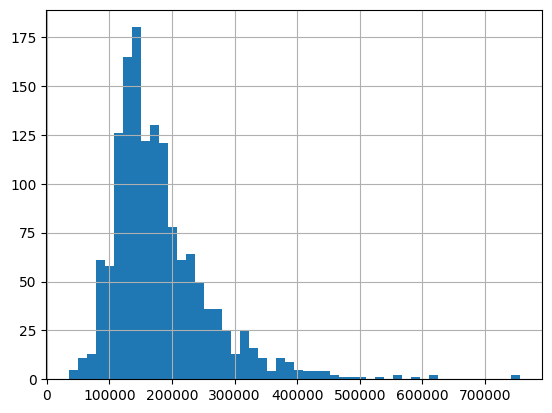

In [8]:
houses_raw['SalePrice'].hist(bins=50)

I see heavy tail distribution. Propably I will use log function to achive Gauss's distributin which is needed to proper work of ML functions.

2) Correlations with 'SalePrice'

<Axes: ylabel='None'>

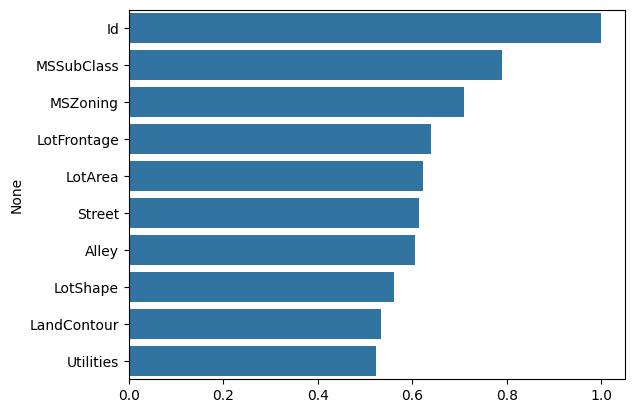

In [9]:
import seaborn as sns

corr_matrix = houses_raw.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
sns.barplot(x = corr_matrix.values[:10], y = houses_raw.columns[:10])

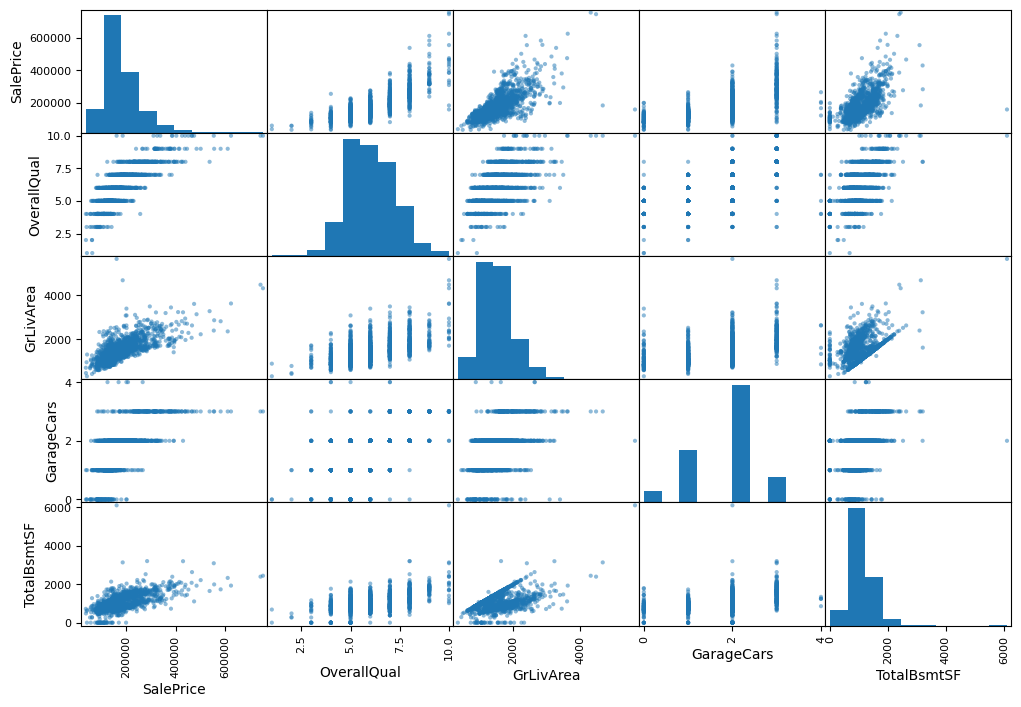

In [10]:
from matplotlib import pyplot as plt
from pandas.plotting import scatter_matrix

attributes = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars','TotalBsmtSF']
scatter_matrix(houses_raw[attributes], figsize=(12, 8))
plt.show()

In [11]:
attributes2 = ['SalePrice', '1stFlrSF', 'FullBath', 'YearBuilt', 'TotRmsAbvGrd']

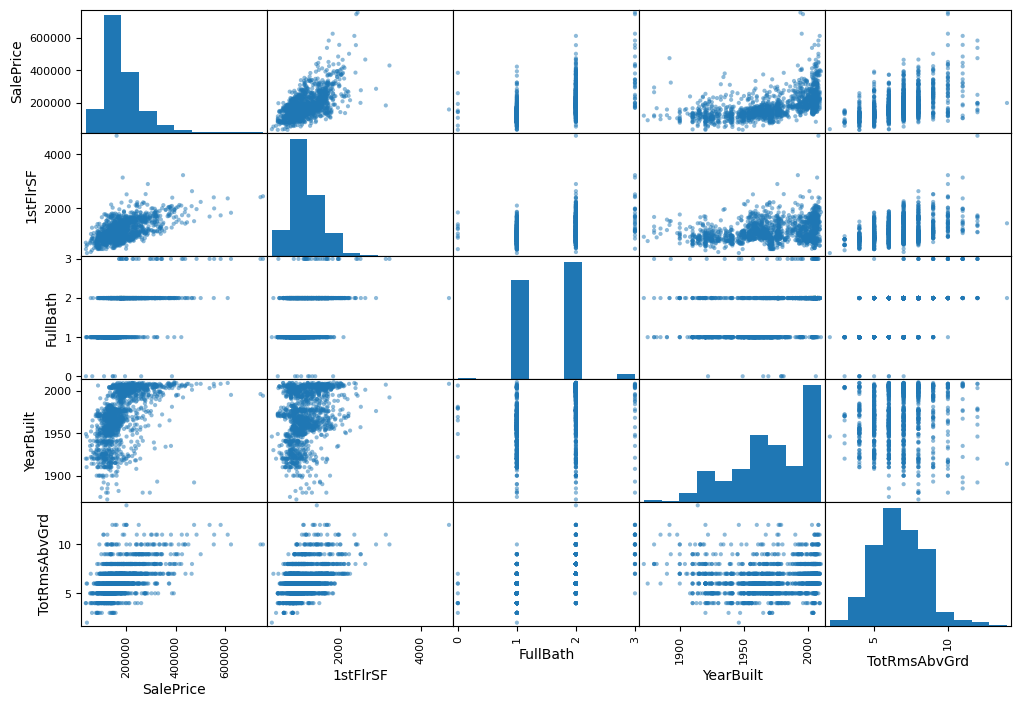

In [12]:
scatter_matrix(houses_raw[attributes2], figsize=(12, 8))
plt.show()

I see which dependencies are the most perspective. I chosen three the best candidates for prediction estate's price.

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

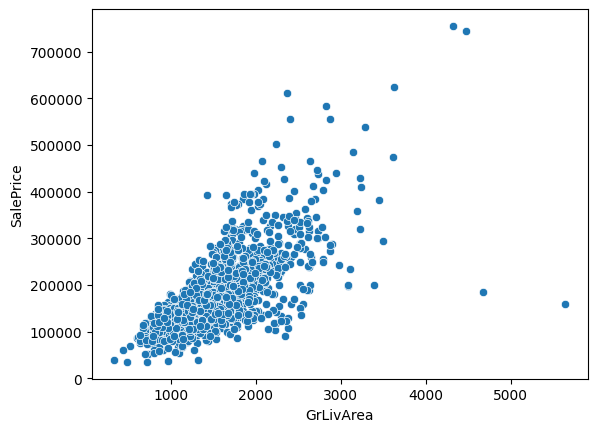

In [13]:
# GrLivArea

sns.scatterplot(x='GrLivArea', y='SalePrice', data=houses_raw)

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

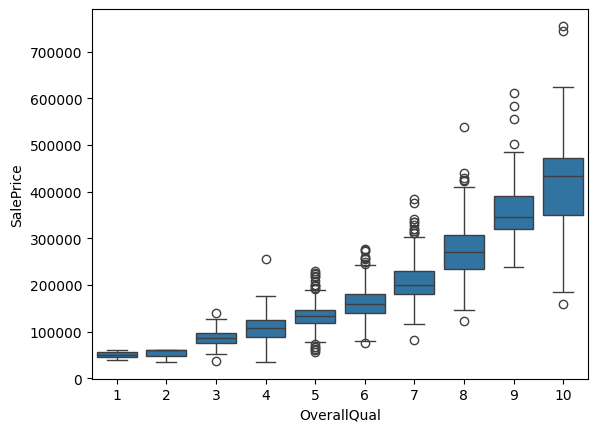

In [14]:
# OverallQual

sns.boxplot(x='OverallQual', y='SalePrice', data=houses_raw)

<Axes: xlabel='GarageCars', ylabel='SalePrice'>

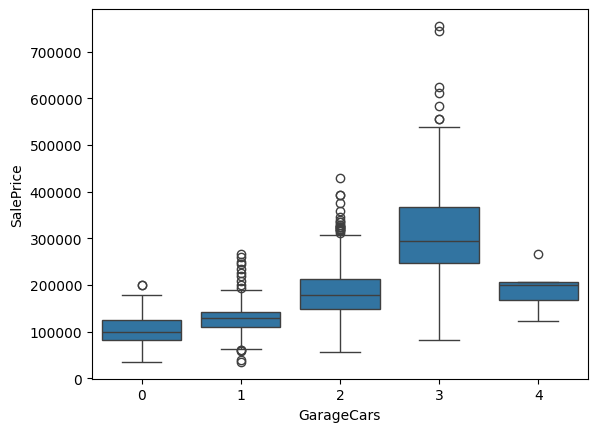

In [15]:
# GarageCars

sns.boxplot(x='GarageCars', y='SalePrice', data=houses_raw)

We see strong correlation between three features and price. Especially OverallQual and GrLivArea have strong rising tendenction in order to price.

3) Na values

<Axes: ylabel='None'>

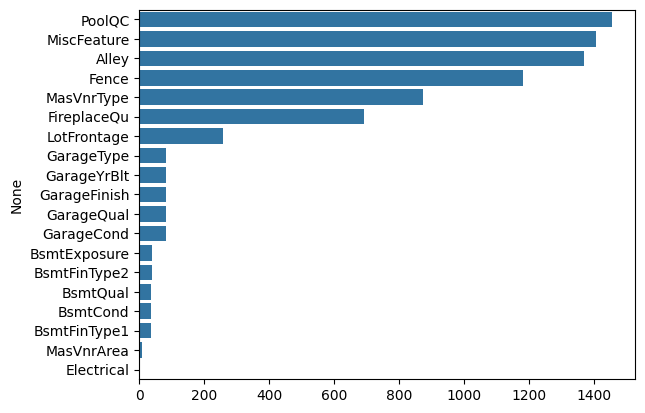

In [16]:
null_df = houses_raw.isnull().sum()
null_df = null_df[null_df > 0].sort_values(ascending=False)
sns.barplot(x=null_df.values, y=null_df.index)

4) Heatmap of correlation

<Axes: >

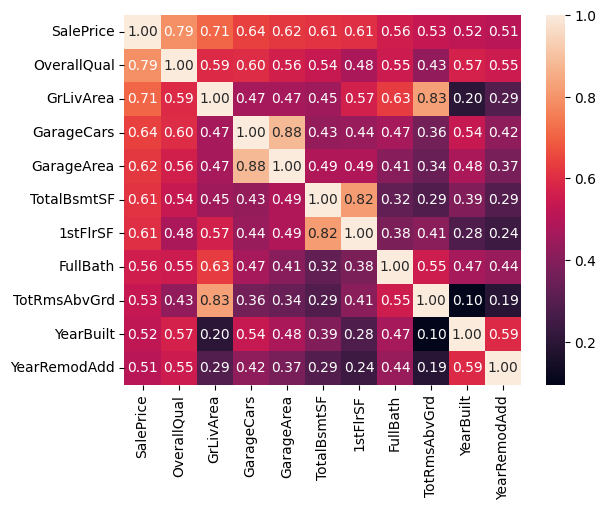

In [17]:
top_features = corr_matrix.index[:11]
sns.heatmap(houses_raw[top_features].corr(), annot=True, fmt=".2f")

Histplot of every numrical features

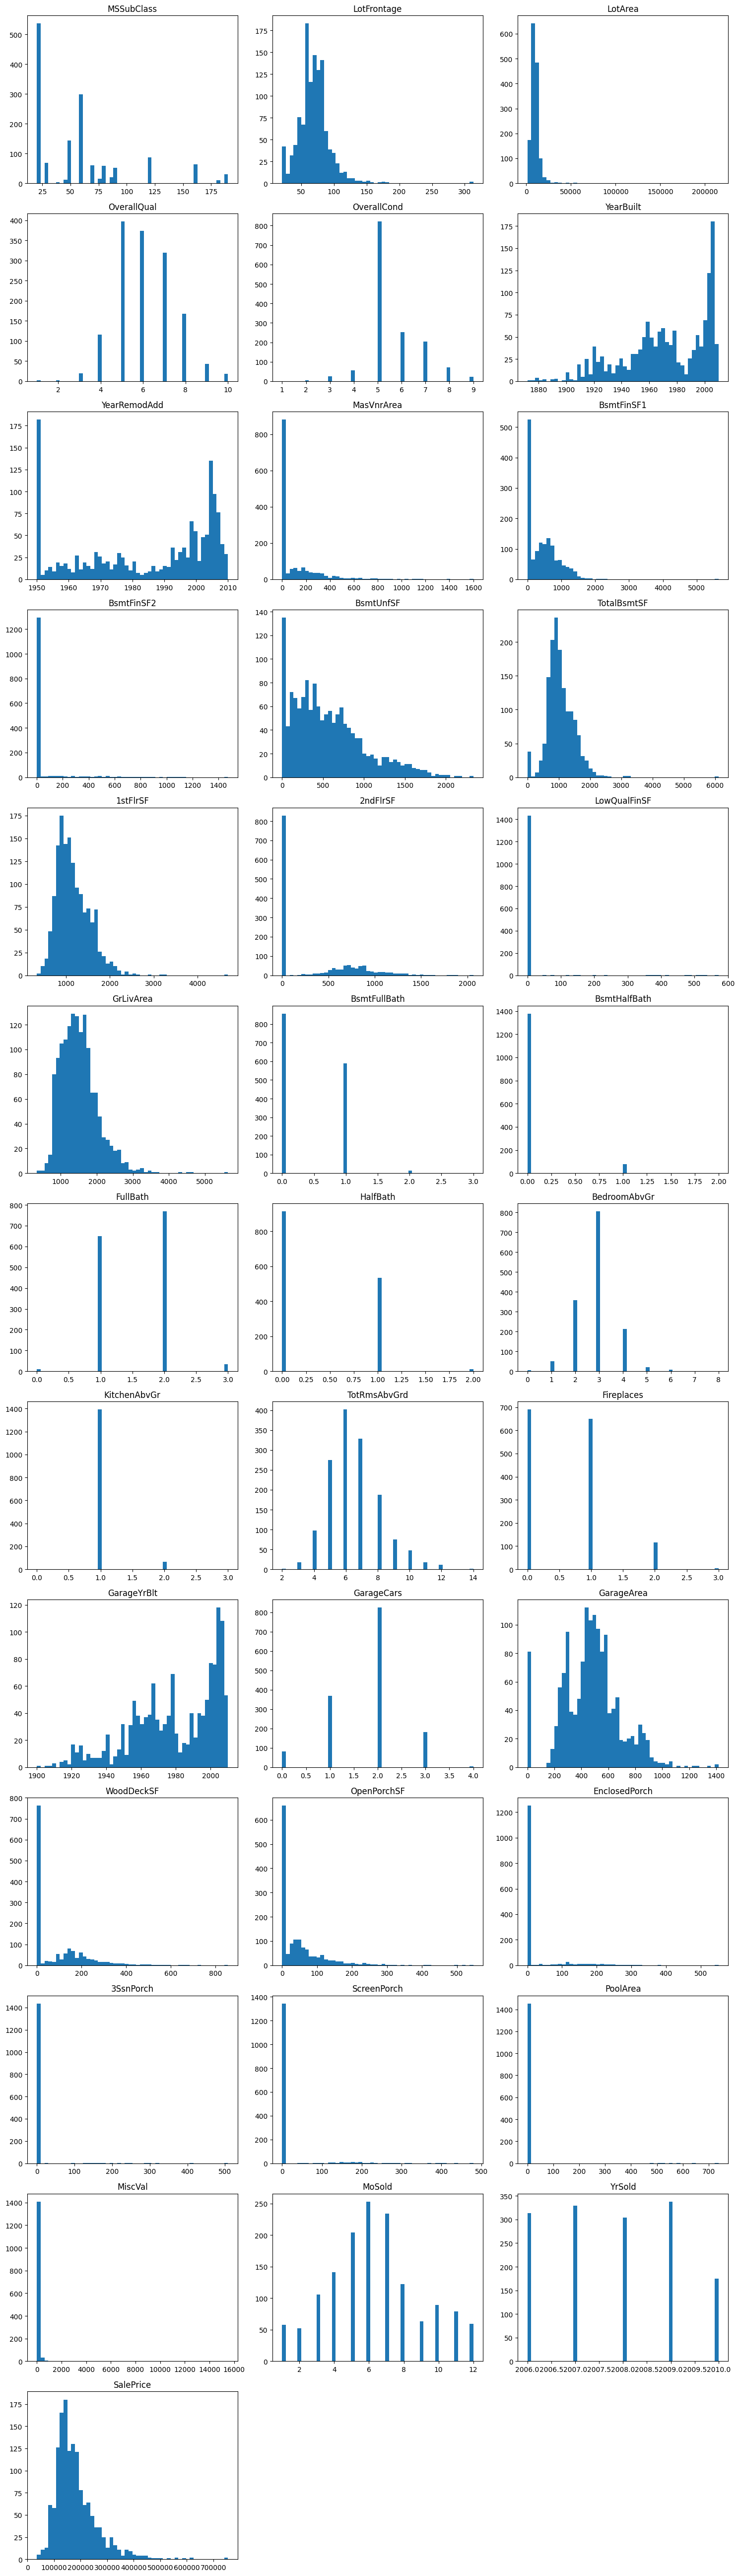

In [18]:
import math

num_features = pd.DataFrame(houses_raw.select_dtypes(include=['float64', 'int64']))
num_features.drop(columns=['Id'], inplace=True)
n = len(num_features.columns)
cols = 3
rows = math.ceil(n / cols)

fig, ax = plt.subplots(rows, cols, figsize=(15, rows * 4))
ax = ax.flatten()

for i, col in enumerate(num_features.columns):
    ax[i].hist(num_features[col].dropna(), bins=50)
    ax[i].set_title(col)

for j in range(i + 1, len(ax)):
    ax[j].set_visible(False)

plt.tight_layout()
plt.show()
